In [1]:
# ensure classes imported from .py files are dynamically updated
%load_ext autoreload
%autoreload 2


# plot matplots nicely
%matplotlib inline  

In [2]:
from stericheight.plotting_fns import PlottingFns
from stericheight.data_handler import GEBCO
from stericheight.utils import Utils
from region import Region
from functions import Functions
from matplotlib.lines import Line2D

pfns = PlottingFns()
fns = Functions()


In [3]:
import gsw
import cartopy
import cmocean
import pandas as pd
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import matplotlib.gridspec as gridspec
import seaborn as sns
import pickle
import warnings

fname_zhou = '../data/CLIM_3D_forJenny.nc'
fname_spira = '../data/qc_profile_ds_2dbar.nc'

In [4]:
elevation_ = GEBCO(coarsen_factor=1).ds.elevation

In [5]:
full_extent = [138, 147,-68,-64]
shelf_comparison_extent = [139,146,-67,-66]

elevation = elevation_.sel(latitude = slice(shelf_comparison_extent[2], shelf_comparison_extent[3]), longitude = slice(shelf_comparison_extent[0],shelf_comparison_extent[1]))


In [6]:
ds = xr.open_dataset('profiles_full.nc')
cdict = pickle.load(open('cdict.pkl','rb'))


In [7]:
ds_shelf = ds.where(ds.elevation
                     > -1000,drop=True)

seasons_meop = fns.get_seasons(ds_shelf)

In [8]:
# choose depth to average over
zz = 300

max_depth = ds_shelf.pres.where(~np.isnan(ds_shelf.temp)).max(dim="pres")
ds_z = ds_shelf.where(max_depth > zz,drop=True).sel(pres=slice(0,zz))


In [27]:
p2d = ds_z.pres.broadcast_like(ds_z.asal)#np.broadcast_to(ds_z.pres.values, ds_z.asal.shape)
dyh = gsw.geo_strf_dyn_height(ds_z.asal,ds_z.ctemp,p2d,300,axis=1) / 9.82##gph(ds_z.rho) 
sth = gsw.geo_strf_steric_height(ds_z.asal,ds_z.ctemp,p2d,300,axis=1) / 9.82##gph(ds_z.rho)

In [28]:
meangph = xr.load_dataarray('meangph.nc')

In [29]:
ds_z['dynh'] = xr.DataArray(dyh,coords={'time':ds_z.time,'pres':ds_z.pres})
ds_z['sth'] = xr.DataArray(sth,coords={'time':ds_z.time,'pres':ds_z.pres})


In [30]:
sha_label = 'SHA (m)'
ds_z[sha_label] = ds_z.dynh.max(dim='pres') - meangph.mean()

In [31]:
n_min = 10

ds_zz = ds_z.mean('pres')
mon_mean_ = ds_zz.resample({'time':'MS'}).mean()
mon_std = ds_zz.resample({'time':'MS'}).std()
mon_count = ds_zz.resample({'time':'MS'}).count()

# make sure all months used have more than n profiles
mon_mean = mon_mean_.where(mon_count > n_min, drop=True)
mon_std = mon_std.where(mon_count > n_min, drop=True)

/home/users/eejco/miniforge3/envs/nemo-env3/lib/python3.14/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/users/eejco/miniforge3/envs/nemo-env3/lib/python3.14/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/users/eejco/miniforge3/envs/nemo-env3/lib/python3.14/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/users/eejco/miniforge3/envs/nemo-env3/lib/python3.14/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/users/eejco/miniforge3/envs/nemo-env3/lib/python3.14/site-packages/numpy/lib/_nanfunctions_impl.py

In [32]:
cli_count = mon_mean.groupby('time.month').count()

cli_mean = mon_mean.groupby('time.month').mean()
cli_std = mon_mean.groupby('time.month').std()

cli_mean = cli_mean.where(cli_count.temp > 1,drop=True)
cli_std = cli_std.where(cli_count.temp >1,drop=True)


/home/users/eejco/miniforge3/envs/nemo-env3/lib/python3.14/site-packages/xarray/structure/concat.py:674: UserWarning: No index created for dimension month because variable month is not a coordinate. To create an index for month, please first call `.set_coords('month')` on this object.
  ds.expand_dims(dim_name, create_index_for_new_dim=create_index_for_new_dim)
/home/users/eejco/miniforge3/envs/nemo-env3/lib/python3.14/site-packages/xarray/structure/concat.py:674: UserWarning: No index created for dimension month because variable month is not a coordinate. To create an index for month, please first call `.set_coords('month')` on this object.
  ds.expand_dims(dim_name, create_index_for_new_dim=create_index_for_new_dim)
/home/users/eejco/miniforge3/envs/nemo-env3/lib/python3.14/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/users/eejco/miniforge3/envs/nemo-env3/lib/

In [33]:
df=mon_mean.groupby('time.month').where(cli_count.temp > 1).to_dataframe()

In [34]:
month_labels = ['J','F','M','A','M','J','J','A','S','O','N','D']
month_values = xr.DataArray(np.arange(1,13),coords={'month':np.arange(1,13)})

/home/users/eejco/miniforge3/envs/nemo-env3/lib/python3.14/site-packages/xarray/structure/concat.py:674: UserWarning: No index created for dimension year because variable year is not a coordinate. To create an index for year, please first call `.set_coords('year')` on this object.
  ds.expand_dims(dim_name, create_index_for_new_dim=create_index_for_new_dim)
/home/users/eejco/miniforge3/envs/nemo-env3/lib/python3.14/site-packages/xarray/structure/concat.py:674: UserWarning: No index created for dimension year because variable year is not a coordinate. To create an index for year, please first call `.set_coords('year')` on this object.
  ds.expand_dims(dim_name, create_index_for_new_dim=create_index_for_new_dim)
/home/users/eejco/miniforge3/envs/nemo-env3/lib/python3.14/site-packages/xarray/structure/concat.py:674: UserWarning: No index created for dimension month because variable month is not a coordinate. To create an index for month, please first call `.set_coords('month')` on this ob

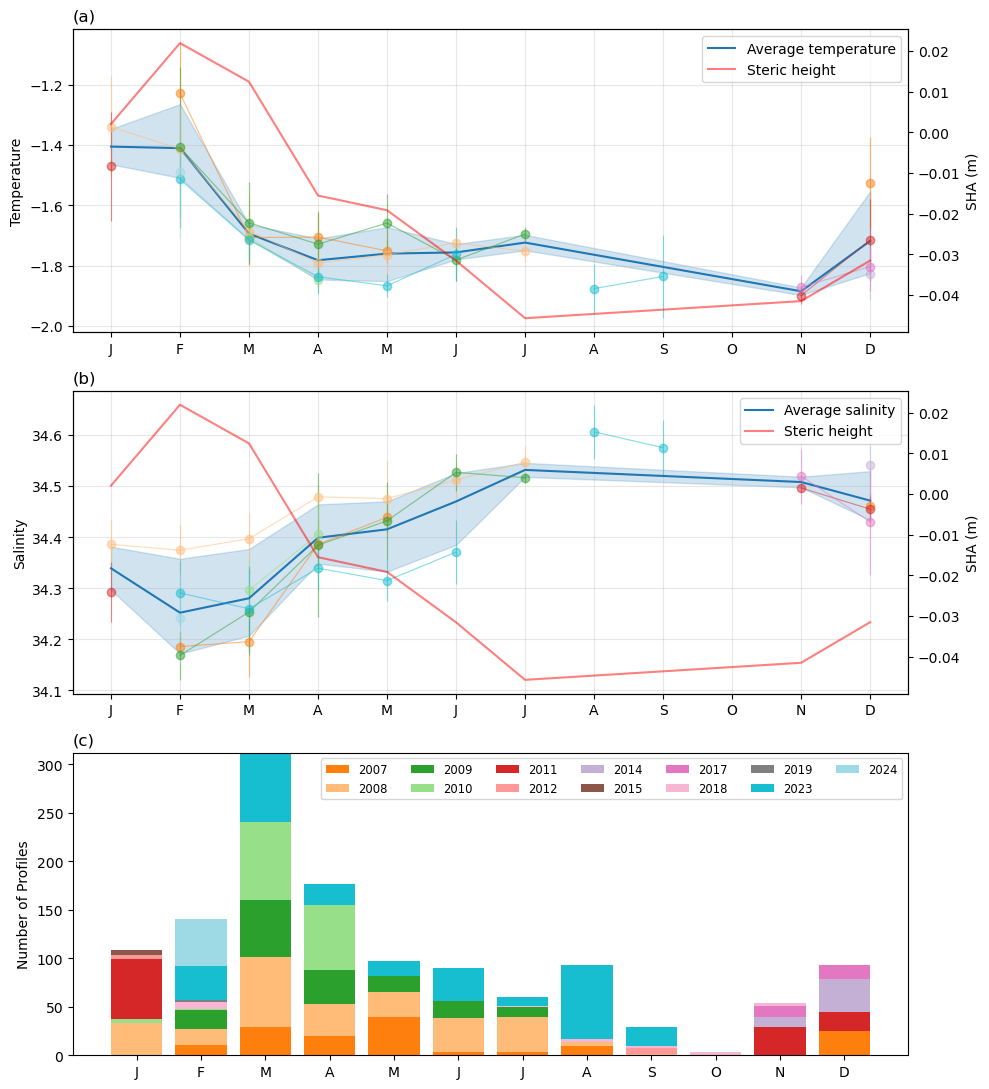

In [35]:
# # plot to demonstrate types of variailty
# dscrop = ds_400.sel(time=slice(pd.Timestamp(2007,1,1),pd.Timestamp(2008,1,1)))
# dscropmon = dscrop.groupby('time.month').mean()
# dscropmonstd = dscrop.groupby('time.month').std()

# fig,axs = plt.subplots(2,1,figsize=(10,5))
# ax=axs[0]
# ax.scatter(dscrop.month,dscrop.temp)
# ax.errorbar(dscropmon.month,dscropmon.temp,yerr=dscropmonstd.temp,c='r')
# ax.set_ylabel('Temperature')
# ax.set_xticks(np.arange(1,13),labels=month_labels)

# ax=axs[1]
# ax.scatter(mon_mean.month,mon_mean.temp)
# ax.errorbar(cli_mean.month,cli_mean.temp,yerr=cli_std.temp,c='r')
# ax.set_ylabel('Temperature')
# ax.set_xticks(np.arange(1,13),labels=month_labels)

# plt.tight_layout()

# mnothly variability plot
fig,axs = plt.subplots(3,1,figsize=(10,11))
mon_year = mon_mean.groupby('time.year').mean()
moc_year = mon_count.where(mon_count.temp).groupby('time.year').count()


ax=axs[0]
cx=axs[1]
bx=axs[2]

for y_da in moc_year.year:
    y = y_da.item()
    data = mon_mean.where(mon_mean.year==y,drop=True)
    dats = mon_std.where(mon_mean.year==y,drop=True)

    if not len(data.time) ==0:
        clim = data.groupby('time.month').mean().broadcast_like(month_values)
        clis = dats.groupby('time.month').mean().broadcast_like(month_values)

        # temperature
        ax.errorbar(clim.month,clim.temp,yerr=clis.temp,marker='o',alpha=0.5,linewidth=0.85,c=cdict[y])
        
        # salinity
        cx.errorbar(clim.month,clim.psal,yerr=clis.psal,marker='o',alpha=0.5,linewidth=0.85,c=cdict[y])

    # histogram
    year_count = mon_count.temp.where(mon_mean_.year==y,drop=True)
    if len(year_count) > 0:
        year_count = np.nan_to_num(year_count.groupby('time.month').mean().broadcast_like(month_values))
        if y > 2007:
            bx.bar(month_values, year_count, bottom = bottom,color=cdict[y],label=str(y))
            bottom = bottom + year_count
        else:
            bx.bar(month_values, year_count,color=cdict[y],label=str(y))
            bottom = year_count.copy()
        

#ax.legend(loc='best',fontsize=2)
bx.legend(ncol=7,fontsize='small')
bx.set_ylabel('Number of Profiles')
bx.set_xticks(np.arange(1,13),labels=month_labels)


sns.lineplot(
    data=df,
    x="month", y="temp", errorbar=("pi",90), ax=ax, 
)
sns.lineplot(
    data=df,
    x="month", y=sha_label, errorbar=None, ax=ax.twinx(), color='r', alpha=0.5, 
)

        
sns.lineplot(
    data=df,
    x="month", y="psal", errorbar=("pi",90), ax=cx
)
sns.lineplot(
    data=df,
    x="month", y=sha_label, errorbar=None, ax=cx.twinx(), color='r', alpha=0.5, 
)

legend_elements = [Line2D([0],[0],label='Average temperature'),
                   Line2D([0],[0],color='r',alpha=0.5,label='Steric height')]
ax.grid(alpha=0.3)
ax.set_xticks(np.arange(1,13),labels=month_labels)
ax.set_ylabel('Temperature')
ax.set_xlabel(None)
ax.legend(handles=legend_elements)

legend_elements = [Line2D([0],[0],label='Average salinity'),
                   Line2D([0],[0],color='r',alpha=0.5,label='Steric height')]
cx.grid(alpha=0.3)
cx.set_xticks(np.arange(1,13),labels=month_labels)
cx.set_ylabel('Salinity')
cx.set_xlabel(None)
cx.legend(handles=legend_elements)

ax.set_title('(a)',loc='left')
cx.set_title('(b)',loc='left')
bx.set_title('(c)',loc='left')

plt.tight_layout()



Text(34.51, 0.03, '1cm ~ -0.042psu')

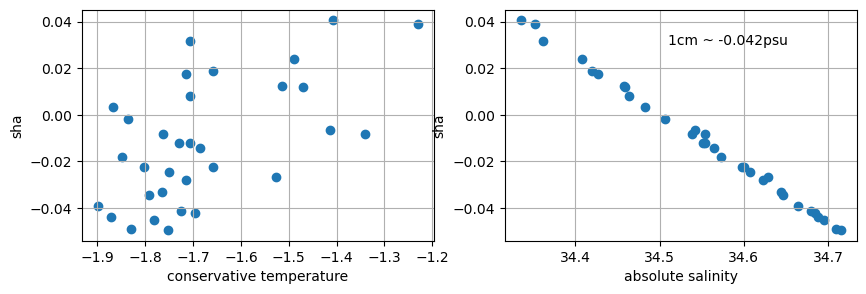

In [39]:
fig, ax = plt.subplots(1,2,figsize=(10,3))

ax[0].scatter(df.ctemp,df[sha_label])
ax[1].scatter(df.asal,df[sha_label])

ax[0].set_ylabel('sha')
ax[0].grid()
ax[0].set_xlabel('conservative temperature')

ax[1].set_ylabel('sha')
ax[1].grid()
ax[1].set_xlabel('absolute salinity')

s,i = np.polyfit(mon_mean[sha_label], mon_mean.asal, 1)
ax[1].text(34.51,0.03,'1cm ~ {}psu'.format(np.round(s,2)/100))

In [19]:
mon_mean = ds_shelf.resample({'time':'MS'}).mean()
mon_std = ds_shelf.resample({'time':'MS'}).std()
mon_quants = ds_shelf.resample({'time':'MS'}).quantile([0.1,0.9])
mon_iqr = mon_quants.sel(quantile=0.9) - mon_quants.sel(quantile=0.1)
mon_count = ds_shelf.resample({'time':'MS'}).count()

# make sure all months used have more than n profiles
mon_mean = mon_mean.where(mon_count > n_min, drop=True)
mon_std = mon_std.where(mon_count > n_min, drop=True)
mon_iqr = mon_iqr.where(mon_count > n_min, drop=True)

cli_count = mon_mean.groupby('time.month').count().broadcast_like(cli_count)
cli_mean = mon_mean.groupby('time.month').mean().broadcast_like(cli_count)
cli_std = mon_mean.groupby('time.month').std().broadcast_like(cli_count)
cli_quants = mon_mean.drop_vars(['month']).groupby('time.month').quantile([0.1,0.9]).broadcast_like(cli_count)
cli_iqr = cli_quants.sel(quantile=0.9) - cli_quants.sel(quantile=0.1).broadcast_like(cli_count)




# make sure all months used have more than n profiles
# cli_mean = cli_mean.where(cli_count.temp > 1,drop=True)
# cli_std = cli_std.where(cli_count.temp >1,drop=True)
# cli_iqr = cli_iqr.where(cli_count.temp >1,drop=True)


/home/users/eejco/miniforge3/envs/nemo-env3/lib/python3.14/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/users/eejco/miniforge3/envs/nemo-env3/lib/python3.14/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/users/eejco/miniforge3/envs/nemo-env3/lib/python3.14/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/users/eejco/miniforge3/envs/nemo-env3/lib/python3.14/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/users/eejco/miniforge3/envs/nemo-env3/lib/python3.14/site-packages/numpy/lib/_nanfunctions_impl.py

In [20]:
mask = (cli_count.temp < 2) | np.isnan(cli_count.temp)

hatch_layer = xr.where(mask, 1, np.nan)

Z = hatch_layer.values

Xe = edges(hatch_layer['month'])
Ye = edges(hatch_layer['pres'])

Xe

NameError: name 'edges' is not defined

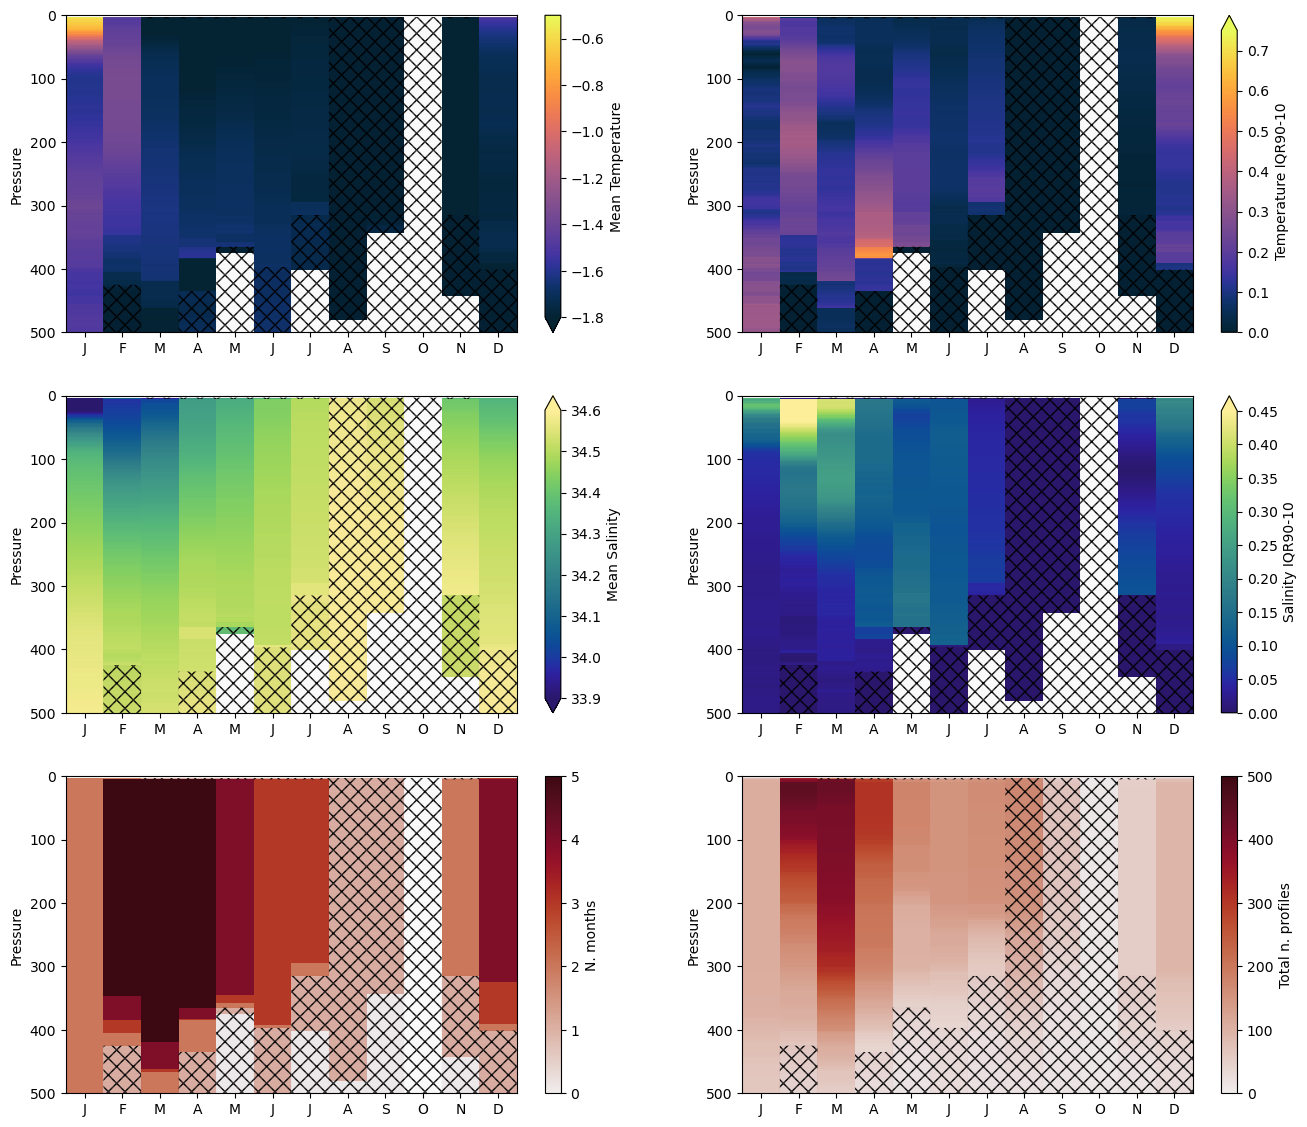

In [21]:
fig, ax = plt.subplots(3,2,figsize=(16,14))

cli_count = cli_count.broadcast_like(month_values)
cli_mean = cli_mean.broadcast_like(month_values)
cli_iqr = cli_iqr.broadcast_like(month_values)

mask = (cli_count.temp < 2) | np.isnan(cli_count.temp)

hatch_layer = xr.where(mask, 1, np.nan)

Z = hatch_layer.values

def edges(coord):
    c = coord.values
    d = np.diff(c)/2
    return np.concatenate(([c[0]-d[0]], c[:-1]+d, [c[-1]+d[-1]]))

Xe = edges(hatch_layer['month'])
Ye = edges(hatch_layer['pres'])

def presvmonth(ax,data,label,cmap,c1=None,c2=None):
    im=data.plot(ax=ax,x='month',y='pres',cmap=cmap,vmin=c1,vmax=c2)

    ax.pcolor(Xe, Ye, Z.T, #hatch_layer,
        alpha=0.01,
        hatch='xx'
    )
        
    ax.invert_yaxis()
    ax.set_ylabel('Pressure')
    im.colorbar.set_label(label)
    ax.set_xticks(np.arange(1,13),labels=month_labels)
    ax.set_xlabel(None)
    ax.set_ylim([500,0])


presvmonth(ax[0][0],cli_mean.temp,'Mean Temperature',cmap=cmocean.cm.thermal,c1=-1.8,c2=-0.5)
presvmonth(ax[0][1],cli_iqr.temp,'Temperature IQR90-10',cmocean.cm.thermal,c1=0,c2=0.75)

presvmonth(ax[1][0],cli_mean.psal,'Mean Salinity',cmap=cmocean.cm.haline,c1=33.9,c2=34.6)
presvmonth(ax[1][1],cli_iqr.psal,'Salinity IQR90-10',cmocean.cm.haline,c1=0,c2=0.45)

presvmonth(ax[2][0],cli_count.temp,'N. months',cmocean.cm.amp,c1=0,c2=5)
presvmonth(ax[2][1],mon_count.psal.groupby('time.month').sum(),'Total n. profiles',cmocean.cm.amp,c1=0,c2=500)


/tmp/ipykernel_953343/3582862085.py:10: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ims.append(ax.scatter(data.asal,data.ctemp,alpha=0.02,c=cdict[y],label=str(y.item())))
/tmp/ipykernel_953343/3582862085.py:10: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ims.append(ax.scatter(data.asal,data.ctemp,alpha=0.02,c=cdict[y],label=str(y.item())))
/tmp/ipykernel_953343/3582862085.py:10: UserWarning: *c* argument looks like a sin

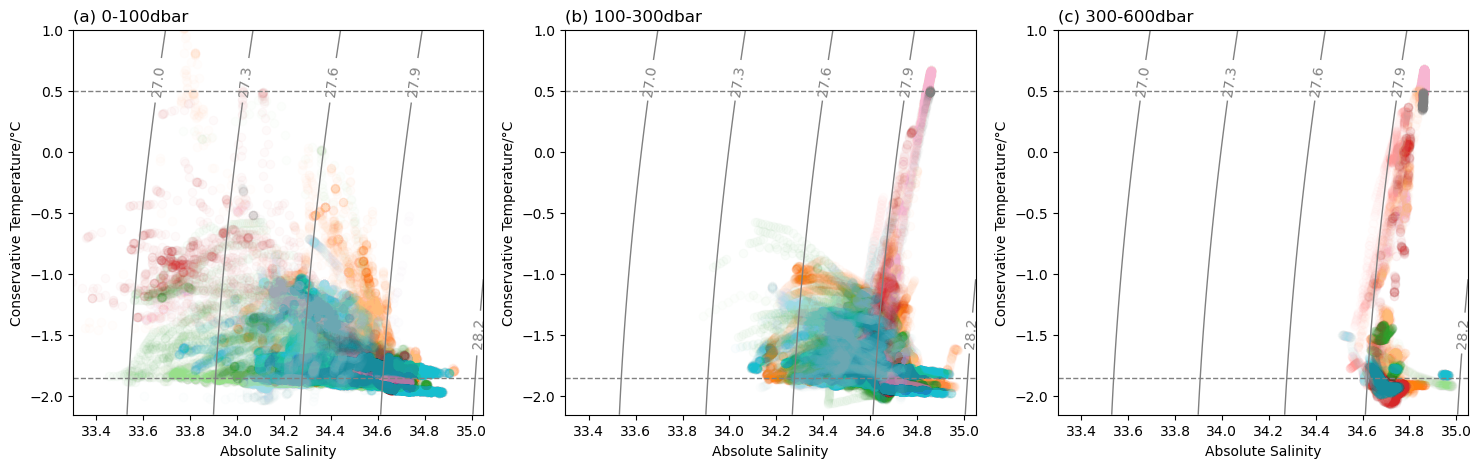

In [37]:
fig, ax = plt.subplots(1,3,figsize=(18,5))

ims=[]
def ts_plot(ax,z1,z2,lbl):
    for y in cdict.keys():
        data = ds_shelf.where(ds_shelf.year==y,drop=True)
        maxz = data.pres.where(~np.isnan(data.temp)).max(dim="pres")
        data = data.where(maxz > z2,drop=True).sel(pres=slice(z1,z2))
        if not len(data.time) ==0:
            ims.append(ax.scatter(data.asal,data.ctemp,alpha=0.02,c=cdict[y],label=str(y.item())))

            

    tlim=[-2.15,1]
    slim=[33.3,35.05]
    temprange,psalrange,sig0range_ = fns.sig0range(tlim,slim)
    cs=ax.contour(psalrange,temprange,sig0range_,levels=[27.0,27.3,27.6,27.88,28.2],colors='grey',linewidths=1)
    plt.clabel(cs, fontsize=10, inline=1, fmt='%0.1f')
    ax.set_xlim(slim)
    ax.set_ylim(tlim)
    ax.set_ylabel('Conservative Temperature/°C')
    ax.set_xlabel('Absolute Salinity')
    ax.set_title(lbl,loc='left')

    ax.plot([slim[0],slim[1]],[-1.85,-1.85],c='grey',ls='--',linewidth=1)
    ax.plot([slim[0],slim[1]],[0.5,0.5],c='grey',ls='--',linewidth=1)


ts_plot(ax[0],0,100,lbl='(a) 0-100dbar')
ts_plot(ax[1],100,300,lbl='(b) 100-300dbar')
ts_plot(ax[2],300,600,lbl='(c) 300-600dbar')


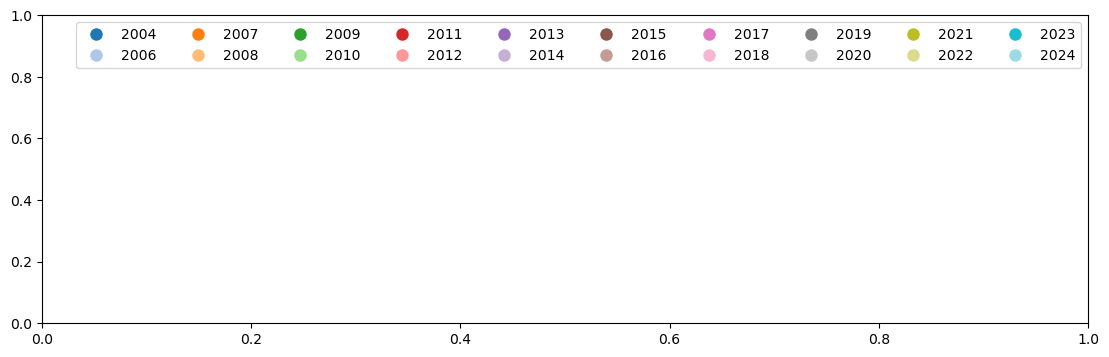

In [31]:
legend_elements = [Line2D([0],[0], color='w', markerfacecolor=cdict[y], marker='o', markersize=10, label=y) for y in cdict.keys()]
fig,ax = plt.subplots(figsize=(13.5,4))
ax.legend(handles=legend_elements,loc='best',ncol=10)

/tmp/ipykernel_953343/790599092.py:12: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ims.append(ax.scatter(data.asal,data.ctemp,alpha=0.02,c=cdict[y],label=str(y.item())))
/tmp/ipykernel_953343/790599092.py:12: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ims.append(ax.scatter(data.asal,data.ctemp,alpha=0.02,c=cdict[y],label=str(y.item())))
/tmp/ipykernel_953343/790599092.py:12: UserWarning: *c* argument looks like a single

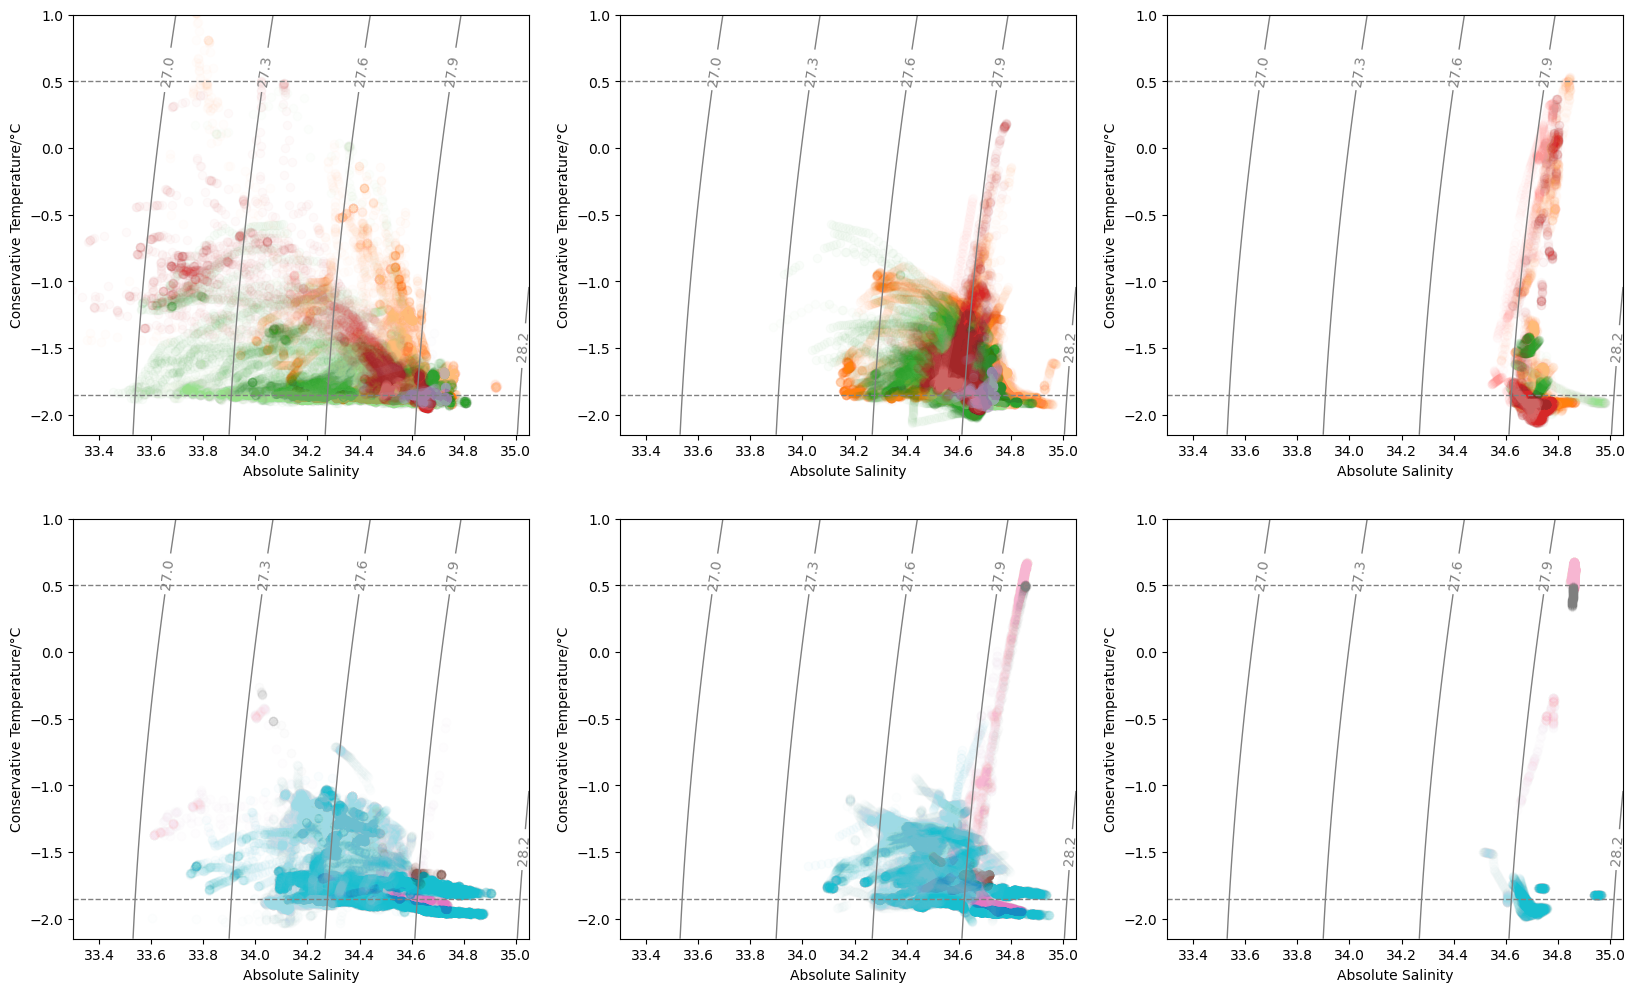

In [23]:
fig, axs = plt.subplots(2,3,figsize=(20,12))

ims=[]
def ts_plot(ax,z1,z2,pre2014=True):
    for y in cdict.keys():
        cond = (y <= 2014) if pre2014 else (y > 2014)
        if cond:
            data = ds_shelf.where(ds_shelf.year==y,drop=True)
            maxz = data.pres.where(~np.isnan(data.temp)).max(dim="pres")
            data = data.where(maxz > z2,drop=True).sel(pres=slice(z1,z2))
            if not len(data.time) ==0:
                ims.append(ax.scatter(data.asal,data.ctemp,alpha=0.02,c=cdict[y],label=str(y.item())))

            

    tlim=[-2.15,1]
    slim=[33.3,35.05]
    temprange,psalrange,sig0range_ = fns.sig0range(tlim,slim)
    cs=ax.contour(psalrange,temprange,sig0range_,levels=[27.0,27.3,27.6,27.88,28.2],colors='grey',linewidths=1)
    plt.clabel(cs, fontsize=10, inline=1, fmt='%0.1f')
    ax.set_xlim(slim)
    ax.set_ylim(tlim)
    ax.set_ylabel('Conservative Temperature/°C')
    ax.set_xlabel('Absolute Salinity')

    ax.plot([slim[0],slim[1]],[-1.85,-1.85],c='grey',ls='--',linewidth=1)
    ax.plot([slim[0],slim[1]],[0.5,0.5],c='grey',ls='--',linewidth=1)

ax=axs[0]
ts_plot(ax[0],0,100)
ts_plot(ax[1],100,300)
ts_plot(ax[2],300,600)

ax=axs[1]
ts_plot(ax[0],0,100,False)
ts_plot(ax[1],100,300,False)
ts_plot(ax[2],300,600,False)
